In [1]:
import sys

repo_path = '/home/emaragliano/Work/Projects/Dottorato/baorecon'
sys.path.insert(0, repo_path)

import os
import numpy as np
import matplotlib.pyplot as plt

from zeldareco.pipeline import ReconstructionPipeline

/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
pipeline = ReconstructionPipeline(
    config_file='bao_pipeline_example.yaml',
)

2026-05-28 11:59:44,448 - zeldareco.io.config - INFO - Loaded reconstruction config from bao_pipeline_example.yaml


In [4]:
saved_paths = pipeline.run()

2026-05-28 12:04:24,137 - zeldareco.io.catalog_io - INFO - Loaded catalogs: data=736756, random=37694049


2026-05-28 12:04:33,244 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Starting BAO reconstruction (IFFT)...
2026-05-28 12:04:33,246 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Reconstruction type: rec-sym, RSD space: RedshiftSpace
2026-05-28 12:04:33,247 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - ============================================================
2026-05-28 12:04:33,247 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - BAO Reconstruction (IFFT) Information:
2026-05-28 12:04:33,248 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - ============================================================
2026-05-28 12:04:33,248 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Mesh: 256^3 points
2026-05-28 12:04:33,248 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Box size: 2480.752197265625 Mpc/h
2026-05-28 12:04:33,249 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Box centre: [ 871.27386 1132.7153  1658.367  

In [7]:
saved_paths.keys()

dict_keys(['data_catalog', 'random_catalog', 'grid_potential', 'grid_displacement', 'reconstructor_object', 'metadata'])

# Read outputs

In [8]:
# read saved catalogs
from astropy.io import fits
rec_data = fits.open(saved_paths['data_catalog'])
grid_potential = fits.open(saved_paths['grid_potential'])



In [35]:
rec_data[1].data.columns

ColDefs(
    name = 'RA'; format = 'D'
    name = 'DEC'; format = 'D'
    name = 'true_redshift_gal'; format = 'E'
    name = 'observed_redshift_gal'; format = 'E'
    name = 'id'; format = 'K'
    name = 'my_flux'; format = 'E'
    name = 'REDSHIFT'; format = 'D'
    name = 'type'; format = 'J'
    name = 'SELECTION'; format = 'L'
    name = 'WEIGHT'; format = 'D'
    name = 'OBJECT_ID'; format = 'K'
    name = 'S_X'; format = 'D'
    name = 'S_Y'; format = 'D'
    name = 'S_Z'; format = 'D'
)

## positions

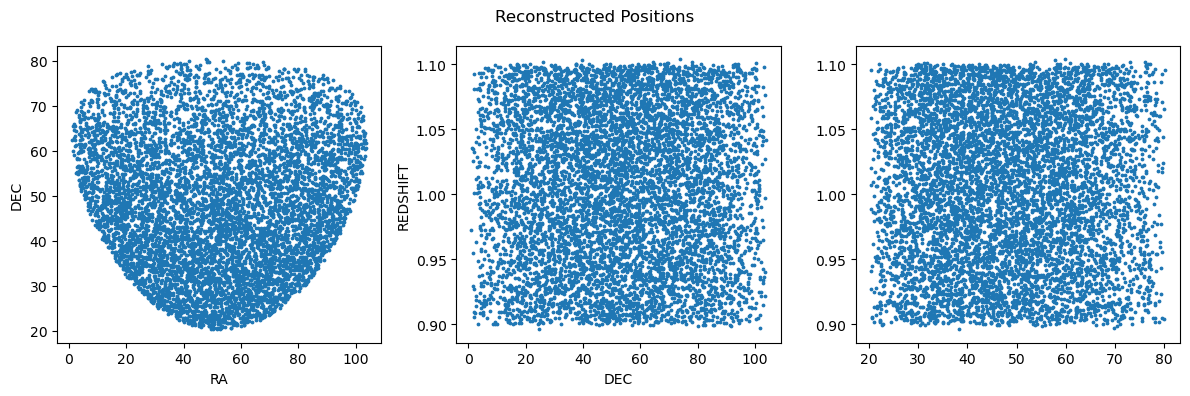

In [11]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Reconstructed Positions')
axs[0].scatter(
    rec_data[1].data['RA'][::100],
    rec_data[1].data['DEC'][::100],
    s=3
)
axs[0].set_xlabel('RA')
axs[0].set_ylabel('DEC')

axs[1].scatter(
    rec_data[1].data['RA'][::100],
    rec_data[1].data['REDSHIFT'][::100],
    s=3
)
axs[1].set_xlabel('RA')
axs[1].set_ylabel('REDSHIFT')

axs[2].scatter(
    rec_data[1].data['DEC'][::100],
    rec_data[1].data['REDSHIFT'][::100],
    s=3
)
axs[1].set_xlabel('DEC')
axs[1].set_ylabel('REDSHIFT')
plt.tight_layout()

## displacement of tracers

Text(0.5, 0, '$||\\psi||$')

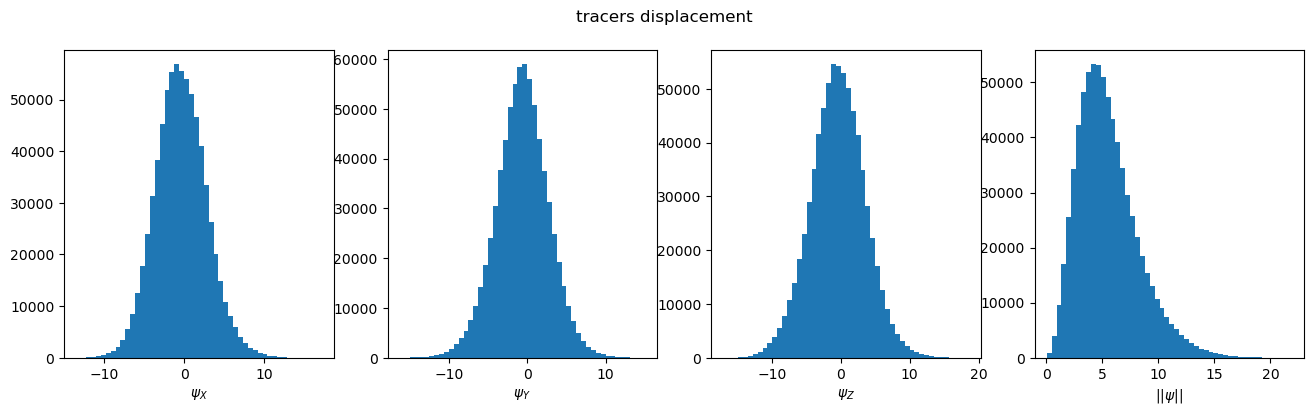

In [34]:
fig, axs = plt.subplots(1,4,figsize=(16,4))
fig.suptitle('tracers displacement')
comps = ['X', 'Y', 'Z']
for i, ax in enumerate(axs[:3]):
    c = comps[i]
    ax.hist(rec_data[1].data[f'S_{c}'], bins=50)
    ax.set_xlabel(f'$\psi_{c}$')

s_norm = np.linalg.norm(np.array([
    rec_data[1].data['S_X'],
    rec_data[1].data['S_Y'],
    rec_data[1].data['S_Z']
]), axis=0)

# Rimosso l'argomento non valido axs=0
axs[3].hist(s_norm, bins=50)
axs[3].set_xlabel('$||\psi||$')

## grid displacement and potential


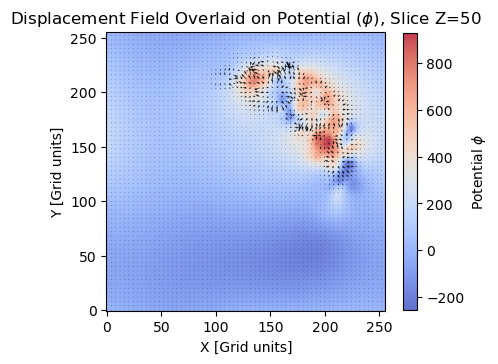

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Load both datasets
with fits.open(saved_paths['grid_displacement']) as hdul:
    psi_data = hdul[0].data  # Shape: (3, Nx, Ny, Nz) or similar

with fits.open(saved_paths['grid_potential']) as pdul:
    phi_data = pdul[0].data  # Shape: (Nx, Ny, Nz)

# 2. Extract the slice at Z = 50
# Displacement components
step = 4
U = psi_data[::step, ::step, 50, 0]
V = psi_data[::step, ::step, 50, 1]

# Potential field at the same slice
# (Keep full resolution for the background image so it looks smooth)
phi_slice = phi_data[:, :, 50]

# 3. Plotting
fig, ax = plt.subplots(figsize=(4.5, 4.5))

# Plot the potential as a smooth background heatmap
# 'origin=lower' is crucial to keep FITS coordinate orientation consistent
im = ax.imshow(phi_slice, origin='lower', cmap='coolwarm', alpha=0.8)
fig.colorbar(im, ax=ax, label='Potential $\phi$', shrink=0.8, aspect=20,)

# Create matching X, Y coordinate mesh for the downsampled quiver arrows
# This ensures the arrows align perfectly with the background pixel grid
Nx, Ny = phi_slice.shape
X, Y = np.meshgrid(np.arange(0, Nx, step), np.arange(0, Ny, step), indexing='ij')

# Overplot the displacement arrows
ax.quiver(X, Y, U, V, color='black', scale=300.0, alpha=0.9)

ax.set_title("Displacement Field Overlaid on Potential ($\phi$), Slice Z=50")
ax.set_xlabel("X [Grid units]")
ax.set_ylabel("Y [Grid units]")

plt.show()

## pickle object

In [65]:
import pickle
from zeldareco.BAOreconstruction.bao_reconstructor import BAOReconstructor

In [66]:


with open(saved_paths['reconstructor_object'], 'rb') as f:
    reconstructor = pickle.load(f)

# Check what kind of object you just loaded
print(type(reconstructor))

<class 'zeldareco.BAOreconstruction.bao_reconstructor.BAOReconstructor'>


In [67]:
reconstructor.__dict__

{'_padding': 100.0,
 '_nmesh': 256,
 'data_pos': array([[1331.22024219, 2020.39115704,  905.18092935],
        [1249.59968955, 2056.35020062,  917.62685401],
        [1274.251052  , 2051.05538934,  917.70969145],
        ...,
        [1394.92531259,  175.74359437, 1753.88700037],
        [1493.22188603,  178.35523316, 1634.57490971],
        [1356.69768079,  102.86962321, 1846.78980694]]),
 'random_pos': array([[-293.43088008, 1467.69857215, 2105.52594272],
        [1522.32332462, 1012.29308207, 1824.97381975],
        [1232.79977579,   57.50027576, 2268.49782906],
        ...,
        [1711.56081216, 1494.66357789,  956.16350717],
        [ 545.34168701,  216.00003583, 2383.22038282],
        [ 120.04314306, 1698.79736903, 1760.39700657]]),
 '_density_manager': <zeldareco.BAOreconstruction.density_manager.DensityManager at 0x7f49eb937460>,
 '_boxsize': 2480.7522,
 '_boxcentre': array([ 871.27386, 1132.7153 , 1658.367  ], dtype=float32),
 'data_weights': array([1., 1., 1., ..., 1., 1.,